Notebook 05 — K-Nearest Neighbors (KNN)
**Regression** → Predict WQI
**Classification** → Predict Water Quality Category

### Why KNN?
- Simplest intuition in ML — **"show me your neighbors and I'll tell you who you are"**
- No training phase — it memorizes the entire dataset
- For a new sample, finds K closest samples and:
- **Regression** → predicts average WQI of K neighbors
- **Classification** → predicts majority class of K neighbors
- Called a **lazy learner** — all computation happens at prediction time

### Key Parameter — K:
- Small K (e.g. K=1) → very sensitive, overfits
- Large K (e.g. K=100) → too smooth, underfits
- Right K → found by testing multiple values

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)


In [2]:
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("Classes   :", list(le.classes_))

Train size: (15223, 30)
Test  size: (3806, 30)
Classes   : ['Excellent', 'Good', 'Poor', 'Unsuitable for Drinking', 'Very Poor yet Drinkable']


## How KNN Measures Distance
KNN needs to measure "closeness" between samples.
Default metric is **Euclidean distance**:

distance = √((pH₁-pH₂)² + (EC₁-EC₂)² + (TDS₁-TDS₂)² + ...)

This is why **StandardScaler was critical** in preprocessing —
if EC ranges 0–16000 and pH ranges 0–14, EC would completely
dominate the distance calculation without scaling.



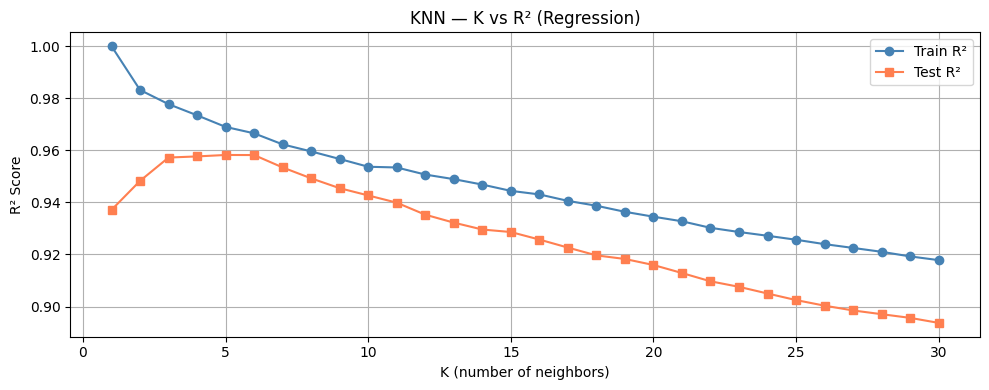

Best K for Regression : 5
Best Test R²          : 0.9582


In [3]:
k_values = range(1, 31)
train_scores, test_scores = [], []

for k in k_values:
  m = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
  m.fit(X_train, y_reg_train)
  train_scores.append(r2_score(y_reg_train, m.predict(X_train)))
  test_scores.append(r2_score(y_reg_test,   m.predict(X_test)))

plt.figure(figsize=(10, 4))
plt.plot(k_values, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(k_values, test_scores,  marker='s', label='Test R²',  color='coral')
plt.xlabel('K (number of neighbors)')
plt.ylabel('R² Score')
plt.title('KNN — K vs R² (Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_reg = test_scores.index(max(test_scores)) + 1
print(f"Best K for Regression : {best_k_reg}")
print(f"Best Test R²          : {max(test_scores):.4f}")

In [4]:
knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg, n_jobs=-1)
knn_reg.fit(X_train, y_reg_train)

y_pred_train = knn_reg.predict(X_train)
y_pred_test  = knn_reg.predict(X_test)

r2_train = r2_score(y_reg_train, y_pred_train)
r2_test  = r2_score(y_reg_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
mae      = mean_absolute_error(y_reg_test, y_pred_test)

print(f"=== KNN Regressor (K={best_k_reg}) ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")

=== KNN Regressor (K=5) ===
R² Train : 0.9690
R² Test  : 0.9582
RMSE     : 66.33
MAE      : 29.62


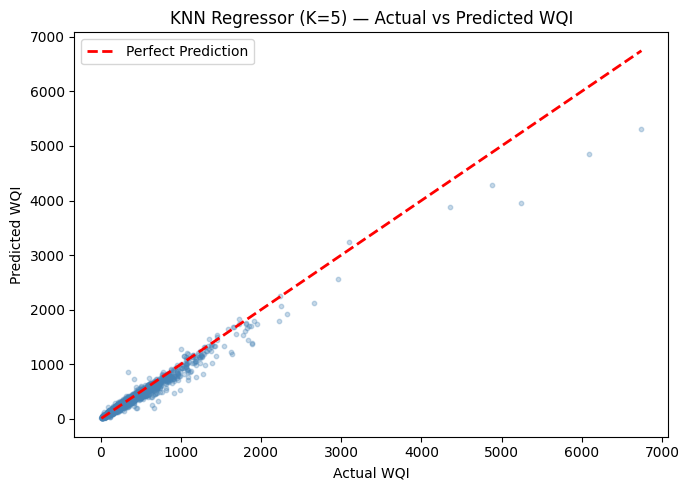

In [5]:
#(Actual vs Predicted Plot)

plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, y_pred_test, alpha=0.3, color='steelblue', s=10)
plt.plot([y_reg_test.min(), y_reg_test.max()],
       [y_reg_test.min(), y_reg_test.max()],
       'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual WQI')
plt.ylabel('Predicted WQI')
plt.title(f'KNN Regressor (K={best_k_reg}) — Actual vs Predicted WQI')
plt.legend()
plt.tight_layout()
plt.show()


## Part 2 — KNN Classifier (Predict Water Quality)



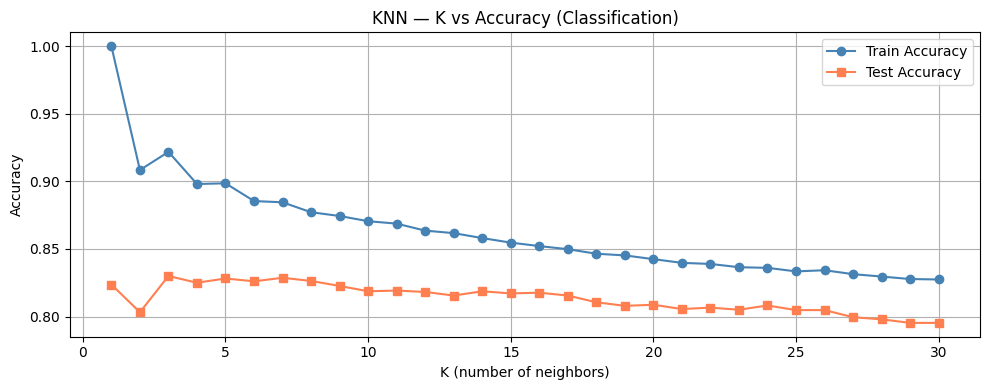

Best K for Classification : 3
Best Test Accuracy        : 0.8300


In [7]:
#(Find Best K — Classification)

train_acc, test_acc = [], []

for k in k_values:
  m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
  m.fit(X_train, y_clf_train)
  train_acc.append(accuracy_score(y_clf_train, m.predict(X_train)))
  test_acc.append(accuracy_score(y_clf_test,   m.predict(X_test)))

plt.figure(figsize=(10, 4))
plt.plot(k_values, train_acc, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(k_values, test_acc,  marker='s', label='Test Accuracy',  color='coral')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN — K vs Accuracy (Classification)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_clf = test_acc.index(max(test_acc)) + 1
print(f"Best K for Classification : {best_k_clf}")
print(f"Best Test Accuracy        : {max(test_acc):.4f}")


In [8]:
#(Train Best KNN Classifier)

knn_clf = KNeighborsClassifier(n_neighbors=best_k_clf, n_jobs=-1)
knn_clf.fit(X_train, y_clf_train)

y_clf_pred_train = knn_clf.predict(X_train)
y_clf_pred_test  = knn_clf.predict(X_test)

acc_train = accuracy_score(y_clf_train, y_clf_pred_train)
acc_test  = accuracy_score(y_clf_test,  y_clf_pred_test)
f1_test   = f1_score(y_clf_test, y_clf_pred_test, average='weighted')

print(f"=== KNN Classifier (K={best_k_clf}) ===")
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")
print(f"F1 Score Test  : {f1_test:.4f}")

=== KNN Classifier (K=3) ===
Accuracy Train : 0.9218
Accuracy Test  : 0.8300
F1 Score Test  : 0.8312


In [9]:
#(Classification Report)

print("=== KNN Classification Report ===")
print(classification_report(
  y_clf_test,
  y_clf_pred_test,
  target_names=le.classes_
))



=== KNN Classification Report ===
                         precision    recall  f1-score   support

              Excellent       0.74      0.85      0.79       136
                   Good       0.70      0.69      0.69       317
                   Poor       0.81      0.85      0.83      1066
Unsuitable for Drinking       0.95      0.89      0.92      1370
Very Poor yet Drinkable       0.75      0.77      0.76       917

               accuracy                           0.83      3806
              macro avg       0.79      0.81      0.80      3806
           weighted avg       0.83      0.83      0.83      3806



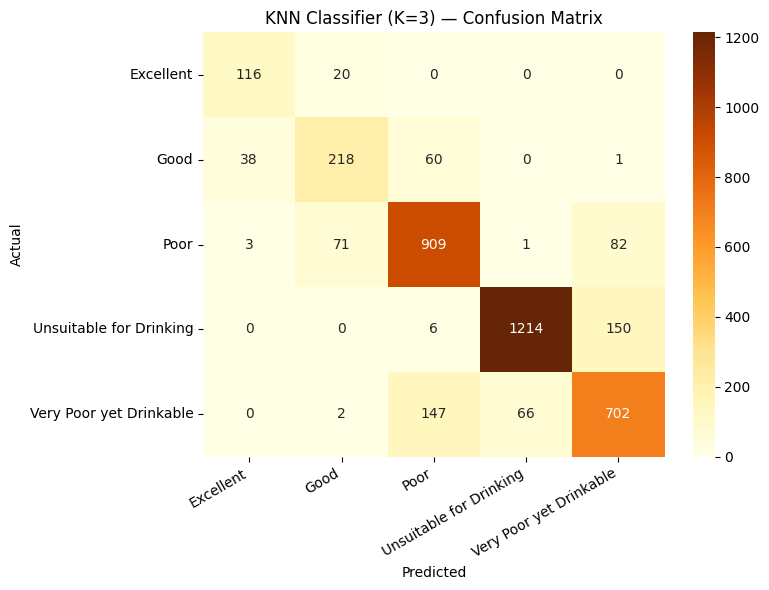

In [10]:
#(Confusion Matrix)

cm = confusion_matrix(y_clf_test, y_clf_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title(f'KNN Classifier (K={best_k_clf}) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [11]:
#(Distance Metrics Comparison)

# Compare different distance metrics at best K
metrics = ['euclidean', 'manhattan', 'chebyshev']
results_metrics = []

for metric in metrics:
  m = KNeighborsClassifier(
      n_neighbors=best_k_clf,
      metric=metric,
      n_jobs=-1
  )
  m.fit(X_train, y_clf_train)
  acc = accuracy_score(y_clf_test, m.predict(X_test))
  f1  = f1_score(y_clf_test, m.predict(X_test), average='weighted')
  results_metrics.append({
      'Distance Metric': metric,
      'Accuracy': round(acc, 4),
      'F1 Score': round(f1, 4)
  })

pd.DataFrame(results_metrics)


,Distance Metric,Accuracy,F1 Score
0,euclidean,0.8300,0.8312
1,manhattan,0.8626,0.8634
2,chebyshev,0.7617,0.7638


In [12]:
#(Full Comparison Table)

with open('results_01_linear_logistic.pkl', 'rb') as f:
  res_01 = pickle.load(f)
with open('results_02_decision_tree.pkl', 'rb') as f:
  res_02 = pickle.load(f)
with open('results_03_random_forest.pkl', 'rb') as f:
  res_03 = pickle.load(f)
with open('results_04_xgboost.pkl', 'rb') as f:
  res_04 = pickle.load(f)

summary = pd.DataFrame([
  {
      'Model': 'Logistic Regression',
      'Acc Test': round(res_01['Logistic Regression']['acc_test'], 4),
      'F1 Test':  round(res_01['Logistic Regression']['f1_test'],  4)
  },
  {
      'Model': 'Decision Tree',
      'Acc Test': round(res_02['Decision Tree Classification']['acc_test'], 4),
      'F1 Test':  round(res_02['Decision Tree Classification']['f1_test'],  4)
  },
  {
      'Model': 'Random Forest',
      'Acc Test': round(res_03['Random Forest Classification']['acc_test'], 4),
      'F1 Test':  round(res_03['Random Forest Classification']['f1_test'],  4)
  },
  {
      'Model': 'XGBoost',
      'Acc Test': round(res_04['XGBoost Classification']['acc_test'], 4),
      'F1 Test':  round(res_04['XGBoost Classification']['f1_test'],  4)
  },
  {
      'Model': f'KNN (K={best_k_clf})',
      'Acc Test': round(acc_test, 4),
      'F1 Test':  round(f1_test,  4)
  }
])

summary


,Model,Acc Test,F1 Test
0,Logistic Regression,0.9611,0.9609
1,Decision Tree,0.9569,0.9570
2,Random Forest,0.9630,0.9629
3,XGBoost,0.9779,0.9779
4,KNN (K=3),0.8300,0.8312


In [13]:
#(Save Results)

results = {
  'KNN Regression': {
      'r2_train': r2_train,
      'r2_test':  r2_test,
      'rmse':     rmse,
      'best_k':   best_k_reg
  },
  'KNN Classification': {
      'acc_train': acc_train,
      'acc_test':  acc_test,
      'f1_test':   f1_test,
      'best_k':    best_k_clf
  }
}

with open('results_05_knn.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Saved. Move on to 06_SVM.ipynb")



Saved. Move on to 06_SVM.ipynb
